# Extended Data Figure 3 — Within-Subject Prediction Variance Violins

Distribution of within-subject prediction std(prob) for correct vs incorrect subjects.  
**Source**: collected prediction parquets  
**Head**: Transformer  
**Tasks**: sex, sleep efficiency (selected per EXT_FIGURES_TASK_SELECTION.md — remaining tasks age/apnea/BMI/depression/OSA stay in S-Fig 20)

In [1]:
%matplotlib inline

In [2]:
import sys
from pathlib import Path

# ── Workspace root: auto-detect by looking for final_results/ ─────────────────
def _find_workspace():
    """Walk up from CWD until we find a directory containing final_results/."""
    candidate = Path.cwd().resolve()
    for _ in range(10):
        if (candidate / "final_results").exists():
            return candidate
        if candidate.parent == candidate:
            break
        candidate = candidate.parent
    # Explicit fallback (edit this if auto-detect fails)
    return Path("/Users/boshra/NSRR-workspace").resolve()

WORKSPACE_ROOT = _find_workspace()
NSRR_TOOLS     = WORKSPACE_ROOT / "NSRR-tools"
FINAL_RESULTS  = WORKSPACE_ROOT / "final_results"
PAPER_FIGURES  = NSRR_TOOLS / "results" / "paper_figures"
FINAL_OUT      = PAPER_FIGURES / "final_npj"
FINAL_OUT.mkdir(parents=True, exist_ok=True)

# Add utils to path (notebooks/utils/)
_nb_dir = PAPER_FIGURES / "notebooks_npj"
sys.path.insert(0, str(_nb_dir))

from utils.style import (
    apply_tbme_style, save_figure, FULL_W, HALF_W,
    MAIN_TASKS, SUPP_TASKS, ALL_TASKS, BINARY_MAIN,
    HEAD_STYLE, TASK_LABEL, FONT_ANNOT, FONT_BASE, FONT_LABEL, FONT_TITLE,
)
from utils.data import set_root, load_analysis, load_heatmap, load_parquets
from utils import panels

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

set_root(WORKSPACE_ROOT)
apply_tbme_style()

# ── Confirm the workspace root is correct ─────────────────────────────────────
_ok = (WORKSPACE_ROOT / "final_results").exists()
print(f"WORKSPACE_ROOT : {WORKSPACE_ROOT}")
print(f"final_results/ : {'✓ found' if _ok else '✗ NOT FOUND — edit _find_workspace() fallback'}")

WORKSPACE_ROOT : /Users/boshra/NSRR-workspace
final_results/ : ✓ found


In [3]:
# Panel labeling helper
def add_panel_label(ax, label, x=0.02, y=0.97):
    ax.text(x, y, label, transform=ax.transAxes,
            fontsize=8, fontweight="bold", va="top", fontfamily="serif")

In [4]:
HEAD   = "transformer"
SPLIT  = "test"
# Extended Data subset (see EXT_FIGURES_TASK_SELECTION.md)
TASKS  = ["sex_binary", "sleep_efficiency_binary"]
SHOW_CONTEXTS = ["30s", "40m", "120m", "240m"]
N_COLS = 2
N_ROWS = (len(TASKS) + N_COLS - 1) // N_COLS

# Load parquets (only contexts we care about)
pqs = {}
for task in TASKS:
    p = load_parquets("phase0_v3", task, HEAD, SPLIT)
    if p:
        pqs[task] = p
print("Tasks with parquets:", sorted(pqs.keys()))

Tasks with parquets: ['sex_binary', 'sleep_efficiency_binary']


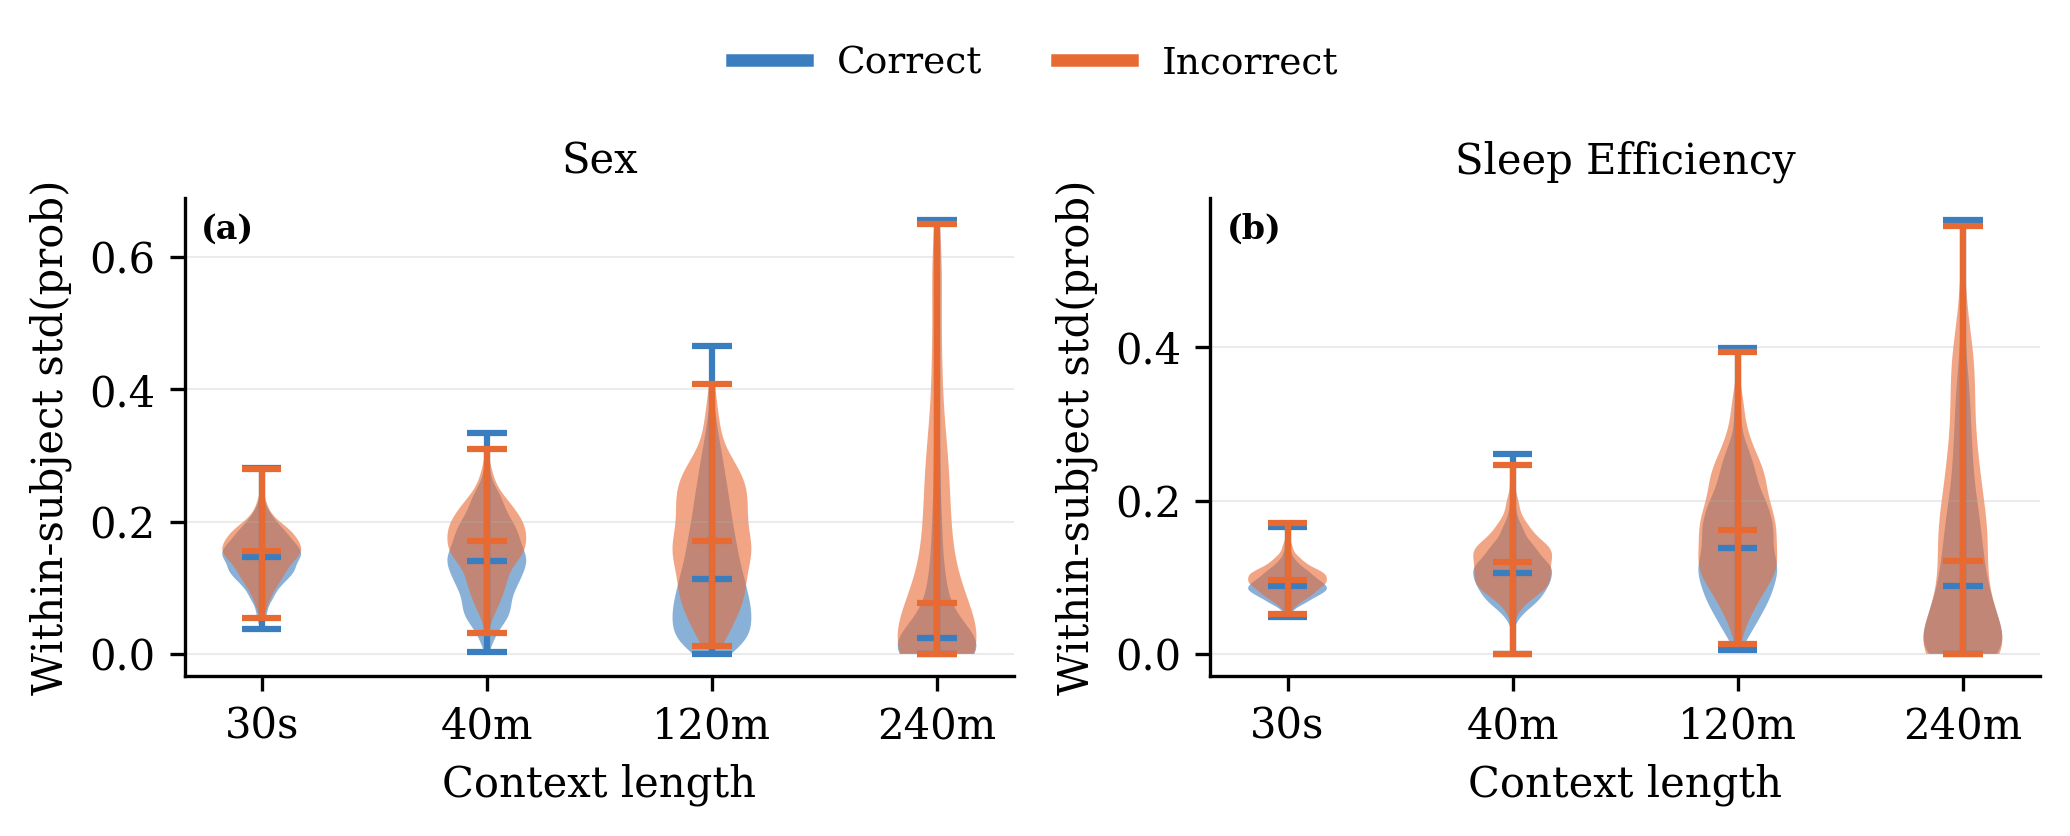

In [16]:
fig, axes = plt.subplots(N_ROWS, N_COLS, figsize=(FULL_W, N_ROWS * 2.3+0.5))
axes_flat = axes.flatten()

plot_tasks = [t for t in TASKS if t in pqs]
for i, (ax, task) in enumerate(zip(axes_flat, plot_tasks)):
    panels.variance_violin_panel(ax, pqs[task], contexts=SHOW_CONTEXTS)
    ax.set_title(TASK_LABEL.get(task, task), fontsize=FONT_TITLE)
    add_panel_label(ax, f"({chr(97+i)})")
    # if i > 0 and ax.get_legend():
    ax.get_legend().remove()

handles, labels = axes_flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2, fontsize=9,
           bbox_to_anchor=(0.5, 1.00), frameon=False)

for ax in axes_flat[len(plot_tasks):]:
    ax.set_visible(False)

fig.tight_layout(rect=[0, 0, 1, 0.90], h_pad=1.5, w_pad=1.0)
plt.show()

In [17]:
# ── Run when figure looks good ──────────────────────────────
save_figure(fig, FINAL_OUT, "ext_fig3_variance_violins")
import shutil
shutil.copy(FINAL_OUT / "ext_fig3_variance_violins.pdf",
            WORKSPACE_ROOT / "npj_digital_medicine_submission" / "ext_fig3_variance_violins.pdf")
print("Saved + copied → npj_digital_medicine_submission/ext_fig3_variance_violins.pdf")

  saved → /Users/boshra/NSRR-workspace/NSRR-tools/results/paper_figures/final_npj/ext_fig3_variance_violins.pdf
Saved + copied → npj_digital_medicine_submission/ext_fig3_variance_violins.pdf
